<a href="https://colab.research.google.com/github/anshulkr69/learning-to-make-machine-learn/blob/main/6_handling_categorical_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Types of Categorical Data:
1. Nominal (can't be ranked i.e. there is no particular priority order of data eg. Branches in a clg, States in a Country...)

2. Ordinal (can be ranked eg. grades)






### The problem with categorical data is that they are not number but objects, and handling objects is way more difficult than numbers because finding correlation b/w objects and studying it using statistics is tricky or even impossible. So we need encoding and therefore we will be studying different types of encoding:




## IMPORTS

In [1]:
import pandas as pd
import numpy as np

# 1. Ordinal Encoding
  -Used on ordinal categorical data
# 2. Label Encoding
-Used on ordinal categorical data

*PS: dono same hi hain, the only difference is that first is used for the input data whereas the later is used for labels/Y/output data
Just different libraries in scikit for different purpose doing same thing.*

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Datasets/customer.csv")

In [ ]:
df.shape

(50, 5)

In [ ]:
df.sample(5)

,age,gender,review,education,purchased
26,53,Female,Poor,PG,No
17,22,Female,Poor,UG,Yes
12,51,Male,Poor,School,No
11,74,Male,Good,UG,Yes
49,25,Female,Good,UG,No


In [ ]:
df = df.iloc[:,2:]
df

,review,education,purchased
0,Average,School,No
1,Poor,UG,No
2,Good,PG,No
3,Good,PG,No
4,Average,UG,No
5,Average,School,Yes
6,Good,School,No
7,Poor,School,Yes
8,Average,UG,No
9,Good,UG,Yes


In [ ]:
df['education'].unique()

array(['School', 'UG', 'PG'], dtype=object)

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(df.drop('purchased',axis=1),df['purchased'],
test_size= 0.2)
x_train.shape,x_test.shape

((40, 2), (10, 2))

In [ ]:
from sklearn.preprocessing import OrdinalEncoder
oe= OrdinalEncoder(categories=[['Poor','Average','Good'],['School','UG','PG']])

In [ ]:
oe.fit(x_train)

OrdinalEncoder(categories=[['Poor', 'Average', 'Good'], ['School', 'UG', 'PG']])

In [ ]:
x_train=oe.transform(x_train)
x_test=oe.transform(x_test)

In [ ]:
x_train

array([[2., 1.],
       [2., 1.],
       [1., 1.],
       [0., 2.],
       [2., 1.],
       [2., 1.],
       [0., 1.],
       [1., 0.],
       [2., 0.],
       [1., 0.],
       [0., 2.],
       [2., 2.],
       [0., 2.],
       [2., 1.],
       [0., 0.],
       [2., 0.],
       [1., 0.],
       [2., 2.],
       [2., 2.],
       [0., 2.],
       [2., 2.],
       [0., 0.],
       [2., 0.],
       [0., 1.],
       [1., 1.],
       [0., 0.],
       [2., 0.],
       [2., 0.],
       [1., 2.],
       [0., 2.],
       [0., 1.],
       [1., 1.],
       [0., 1.],
       [2., 2.],
       [0., 2.],
       [0., 2.],
       [0., 2.],
       [1., 0.],
       [1., 1.],
       [1., 2.]])

In [ ]:
# we dont actually need to change the array into a DF, the scikit learn functions natively
# do that. Basically they can accept both array and DF/Series

x_train=pd.DataFrame(x_train,columns=df.iloc[:,0:2].columns)
x_test=pd.DataFrame(x_test,columns=df.iloc[:,0:2].columns)

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

# WE DON'T PASS CATEGORIES IN LABEL ENCODING!!!

In [ ]:
le.fit(y_train)

LabelEncoder()

In [ ]:
le.classes_

array(['No', 'Yes'], dtype=object)

In [ ]:
y_train=le.transform(y_train)
y_test=le.transform(y_test)

# 3. One-Hot Encoding
-Used for Nominal categorical data.

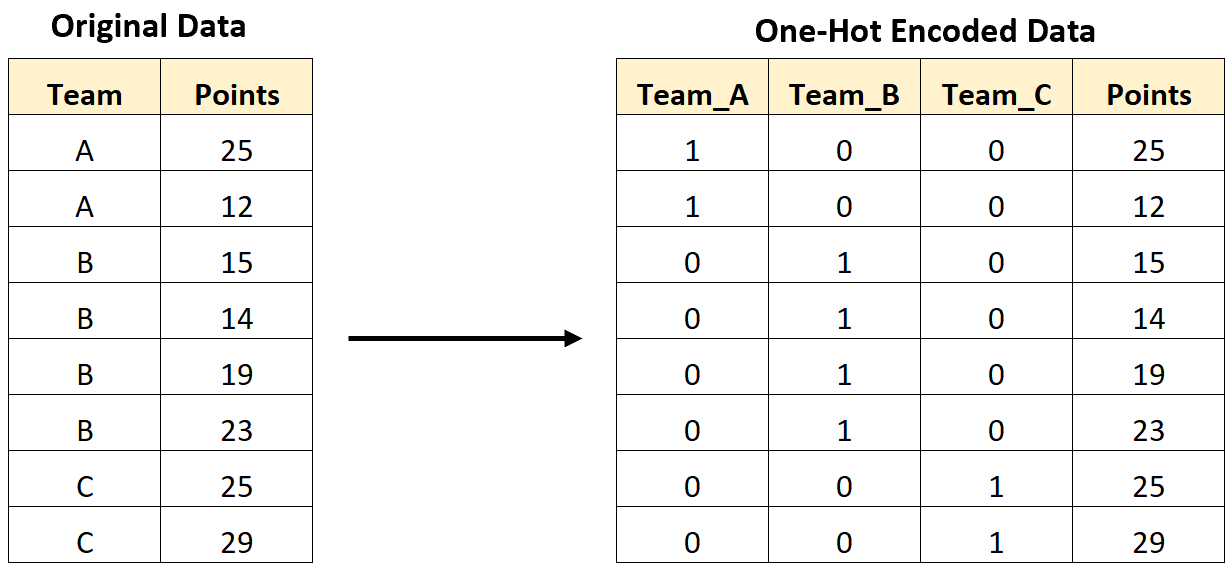

This image illustrates how OneHotEncoding works.


For N categories we make n-1 columns, so from the above example we can simply remove the column for team A
And hence the representations will be like these:

Team_A: 0 0

Team_B: 1 0

Team_C: 0 1

In [2]:
df = pd.read_csv('/content/drive/MyDrive/Datasets/cars.csv')

In [3]:
df.sample(5
        )

,brand,km_driven,fuel,owner,selling_price
5550,Chevrolet,32000,Diesel,First Owner,535000
7267,Mahindra,30000,Diesel,First Owner,700000
5811,Maruti,160000,Diesel,First Owner,350000
107,Hyundai,37800,Petrol,First Owner,866000
810,Maruti,60000,Petrol,First Owner,500000


In [4]:
df['brand'].value_counts()

,count
brand,
Maruti,2448
Hyundai,1415
Mahindra,772
Tata,734
Toyota,488
Honda,467
Ford,397
Chevrolet,230
Renault,228


We can see that many of the brands have very less vehicles, here what we can do is seperate the ones that have more vehicles and perform encoding only on those.

In [6]:
len(df['brand'].unique())

32

In [7]:
df['fuel'].value_counts()

,count
fuel,
Diesel,4402
Petrol,3631
CNG,57
LPG,38


In [8]:
df['owner'].value_counts()

,count
owner,
First Owner,5289
Second Owner,2105
Third Owner,555
Fourth & Above Owner,174
Test Drive Car,5


# OneHotEncoding using Pandas

In [9]:
pd.get_dummies(df,columns=['fuel','owner'])

,brand,km_driven,selling_price,fuel_CNG,fuel_Diesel,fuel_LPG,fuel_Petrol,owner_First Owner,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,Maruti,145500,450000,False,True,False,False,True,False,False,False,False
1,Skoda,120000,370000,False,True,False,False,False,False,True,False,False
2,Honda,140000,158000,False,False,False,True,False,False,False,False,True
3,Hyundai,127000,225000,False,True,False,False,True,False,False,False,False
4,Maruti,120000,130000,False,False,False,True,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
8123,Hyundai,110000,320000,False,False,False,True,True,False,False,False,False
8124,Hyundai,119000,135000,False,True,False,False,False,True,False,False,False
8125,Maruti,120000,382000,False,True,False,False,True,False,False,False,False
8126,Tata,25000,290000,False,True,False,False,True,False,False,False,False


For dropping the first column that is making it
### K-1 OneHotEncoding
we have to write the below code:

In [10]:
pd.get_dummies(df,columns=['fuel','owner'],drop_first=True)

,brand,km_driven,selling_price,fuel_Diesel,fuel_LPG,fuel_Petrol,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,Maruti,145500,450000,True,False,False,False,False,False,False
1,Skoda,120000,370000,True,False,False,False,True,False,False
2,Honda,140000,158000,False,False,True,False,False,False,True
3,Hyundai,127000,225000,True,False,False,False,False,False,False
4,Maruti,120000,130000,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
8123,Hyundai,110000,320000,False,False,True,False,False,False,False
8124,Hyundai,119000,135000,True,False,False,True,False,False,False
8125,Maruti,120000,382000,True,False,False,False,False,False,False
8126,Tata,25000,290000,True,False,False,False,False,False,False


## [OneHotEncoding using Sklearn](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html)

In [51]:
df['brand'].replace(['Nissan', 'Jaguar', 'Volvo', 'Datsun', 'Mercedes-Benz', 'Fiat', 'Audi',
       'Lexus', 'Jeep', 'Mitsubishi', 'Land', 'Force', 'Isuzu', 'Ambassador',
       'Kia', 'MG', 'Daewoo', 'Ashok', 'Opel', 'Peugeot'],'Others',inplace=True)
# this is implemented later. Just copy and pasted it from below. details below

In [53]:
df.sample(5)

,brand,km_driven,fuel,owner,selling_price
2386,Others,120000,Diesel,Second Owner,190000
7819,Mahindra,60000,Diesel,Second Owner,700000
1419,Hyundai,50000,Petrol,Third Owner,220000
2008,Volkswagen,80000,Diesel,Second Owner,425000
3984,Hyundai,60000,Diesel,First Owner,550000


In [40]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test= train_test_split(df.iloc[:,0:4],df.iloc[:,-1],test_size=0.2,random_state=0)

In [41]:
x_train.head()

,brand,km_driven,fuel,owner
3042,Hyundai,60000,LPG,First Owner
1520,Tata,150000,Diesel,Third Owner
2611,Hyundai,110000,Diesel,Second Owner
3544,Mahindra,28000,Diesel,Second Owner
4138,Maruti,15000,Petrol,First Owner


In [87]:
from sklearn.preprocessing import OneHotEncoder
ohe= OneHotEncoder(drop='first',dtype=int)
# if we add sparse=False here then we need not do the array conversion we do below

we will only perform this on fuel and owner because thie scikit learn function does encoding of all the categories present in a column. But for brands we need to only the categories that have more vehicles/ that occupy more rows.

In [88]:
x_train_new= ohe.fit_transform(x_train[['brand','fuel','owner']]).toarray()

In [89]:
x_test_new = ohe.fit_transform(x_test[['brand','fuel','owner']]).toarray()

In [90]:
x_train_new.shape

(6502, 19)

***Some imp shi here:***

In [91]:
x_train['km_driven'].values.shape

(6502,)

In [92]:
# we are basically now combining the encoded array and the brand and km_driven data
encoded = np.column_stack((x_train['km_driven'].values,x_train_new))

# what this does is joins the arrays in the particular order as seen in output
# use hstack() for same dimensional arrays and column stack for different dimension arrays
# .values turns df into array

In [93]:
# To see the order in which these are arranged:

ohe.categories_
ohe.drop_idx_

array([0, 0, 0], dtype=object)

In [94]:
cols=['km_driven']
for i in ohe.categories_:
  for j in range(1,len(i)):
    cols.append(i[j])

In [95]:
len(cols)

20

In [96]:
# Own try to create DF
df_encoded= pd.DataFrame(encoded, columns= cols)
df_encoded

,km_driven,Chevrolet,Ford,Honda,Hyundai,Mahindra,Maruti,Others,Renault,Skoda,Tata,Toyota,Volkswagen,Diesel,LPG,Petrol,Fourth & Above Owner,Second Owner,Test Drive Car,Third Owner
0,60000,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
1,150000,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1
2,110000,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0
3,28000,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0
4,15000,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6497,70000,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1
6498,100000,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0
6499,90000,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0
6500,90000,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0


Now we will be handling the brands column (The details for above used code)

In [28]:
counts= df['brand'].value_counts()

In [36]:
threshold=100
repl= counts[counts<=100].index
repl

Index(['Nissan', 'Jaguar', 'Volvo', 'Datsun', 'Mercedes-Benz', 'Fiat', 'Audi',
       'Lexus', 'Jeep', 'Mitsubishi', 'Land', 'Force', 'Isuzu', 'Ambassador',
       'Kia', 'MG', 'Daewoo', 'Ashok', 'Opel', 'Peugeot'],
      dtype='object', name='brand')

In [39]:
df['brand'].replace(repl,'Others',inplace=True)
df['brand'].unique()

# I will just copy and paste this code above.

/tmp/ipykernel_11241/1370426933.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['brand'].replace(repl,'Others',inplace=True)


array(['Maruti', 'Skoda', 'Honda', 'Hyundai', 'Toyota', 'Ford', 'Renault',
       'Mahindra', 'Tata', 'Chevrolet', 'Others', 'Volkswagen', 'BMW'],
      dtype=object)